# Top-2% total water level at *your* station

Flooding and erosion respond to neither sea level nor waves alone but to their
sum at the shoreline:

$$\mathrm{TWL}(t) = \mathrm{SWL}(t) + R_{2\%}(t)$$

— hourly still-water level from your tide gauge (tides included) plus the
2%-exceedance wave runup on your beach from the Stockdon et al. (2006) formula.
The runup implementation is the research group's own method (ported from
Prof. Merrifield's MATLAB): deep-water wave height and length come from the MOP
frequency spectra, unshoaled band by band, and the beach slope β is a seasonal
fit from satellite shorelines, looked up for your transect.

All the machinery is provided. Your blanks are the two lines where the physics
happens — and the interpretation.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "README.md").exists(), "Open the course project folder first."

UHSLC_RAW = PROJECT_ROOT / "data" / "raw" / "uhslc"
MOP_RAW = PROJECT_ROOT / "data" / "raw" / "mop"
CODE_DL = PROJECT_ROOT / "data" / "code-downloaded"
GRAV = 9.81   # m/s^2

# gauge -> (hourly UHSLC file, wave transect)
SITES = {
    "San Diego":     ("h569.nc",  "D0179"),
    "La Jolla":      ("h554.nc",  "D0513"),
    "Los Angeles":   ("h567a.nc", "L0550"),
    "Port San Luis": ("h565a.nc", "SL075"),
    "Monterey":      ("h555a.nc", "MO832"),
    "San Francisco": ("h551.nc",  "SF029"),
    "Humboldt Bay":  ("h576a.nc", "HU583"),
    "Crescent City": ("h556.nc",  "DN155"),
}

MY_SITE = "San Diego"  # TODO: your group's station

SWL_FILE, MOP_ID = SITES[MY_SITE]
print(MY_SITE, "->", SWL_FILE, "+", MOP_ID)

San Diego -> h569.nc + D0179


## 1. The two hourly ingredients

Still-water level comes from the **hourly** UHSLC file (the hourly sibling of
notebook 11's daily file), in meters, restricted to the MOP era and referenced to
its own mean. The waves come as 20-band hourly frequency spectra.

In [2]:
UHSLC_BASE = "https://uhslc.soest.hawaii.edu/data/netcdf"
MOP_NCSS = "https://thredds.cdip.ucsd.edu/thredds/ncss/point/cdip/model/MOP_alongshore"


def load_hourly_swl(filename):
    """Hourly still-water level in meters, 2000-present, relative to its mean."""
    target = UHSLC_RAW / filename
    if not target.exists():
        # same two-archive fallback as the daily files in notebook 11
        for archive in ("fast/hourly", "rqds/pacific/hourly"):
            try:
                urlretrieve(f"{UHSLC_BASE}/{archive}/{filename}", target)
                break
            except Exception:
                continue
    with xr.open_dataset(target) as ds:
        # mm on the station datum -> meters
        swl = ds["sea_level"].squeeze("record_id", drop=True).to_series() / 1000.0
    swl = swl["2000-01-01":]        # keep only the years the wave model covers
    return swl - swl.mean()         # reference to the record's own mean level


def load_hourly_spectra(mop_id):
    """Hourly energy density (time x 20 bands, m^2/Hz) and model-point depth."""
    parts = []
    for kind in ("hindcast", "nowcast"):
        target = MOP_RAW / f"{mop_id}_{kind}_spectra.nc"
        if not target.exists():
            urlretrieve(f"{MOP_NCSS}/{mop_id}_{kind}.nc?var=waveEnergyDensity"
                        f"&var=waveFlagPrimary&temporal=all&accept=netcdf", target)
            print(f"downloaded {target.name}")
        with xr.open_dataset(target) as ds:
            ds = ds.swap_dims({"obs": "time"})
            energy = pd.DataFrame(ds["waveEnergyDensity"].values,
                                  index=pd.DatetimeIndex(ds["time"].values))
            energy[ds["waveFlagPrimary"].values != 1] = np.nan   # QC mask
            parts.append(energy)
    energy = pd.concat(parts).sort_index()
    energy = energy[~energy.index.duplicated()]
    # the depth of the transect's model point, from the course lookup table
    depth = pd.read_csv(CODE_DL / "mop_transect_coords.csv",
                        index_col="mop_id")["depth"][mop_id]
    return energy, float(depth)


swl = load_hourly_swl(SWL_FILE)
energy, depth = load_hourly_spectra(MOP_ID)
print(f"SWL {swl.index[0]:%Y-%m} to {swl.index[-1]:%Y-%m}; "
      f"spectra to {energy.index[-1]:%Y-%m}; model point at {depth:.0f} m depth")

SWL 2000-01 to 2026-06; spectra to 2026-08; model point at 10 m depth


## 2. Deep-water waves, your beach slope, and runup

Provided machinery, three pieces: linear dispersion (Wu & Thornton 1986), the
band-by-band unshoal to deep water, and the slope lookup.

**TODO (markdown):** run the cell and read your slope line. Is your β a direct
satellite fit? Is your beach steep (β near 0.08) or flat (near 0.01)? Runup
scales with β directly — predict now whether your site's runup will be a large or
small fraction of its wave height.

In [3]:
# the 20 standard MOP frequency bands (Hz) and their bandwidths
MOP_FREQ = np.array([0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.0813,
                     0.09, 0.1, 0.11, 0.1225, 0.14, 0.16, 0.18, 0.2075, 0.25,
                     0.3125, 0.4])
MOP_BW = np.array([0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.0075,
                   0.01, 0.01, 0.01, 0.015, 0.02, 0.02, 0.02, 0.0325, 0.05,
                   0.075, 0.1])


def linear_dispersion(freq, depth):
    """Wavelength, phase speed, group speed for linear waves at one depth.
    Explicit Wu & Thornton (1986) approximation to the dispersion relation."""
    freq = np.asarray(freq, dtype=float)
    a = 4.0243 * depth * freq ** 2
    yhat = a * (1 + 1.26 * np.exp(-1.84 * a))
    t = np.exp(-2 * yhat)
    aka = np.where(a >= 1, a * (1 + 2 * t * (1 + t)),
                   np.sqrt(a) * (1 + (a / 6) * (1 + a / 5)))
    k = np.abs(aka / depth)          # wavenumber 2*pi/L
    L = 2 * np.pi / k                # wavelength (m)
    # cap the deep-water argument: sinh overflows above ~700, where the term is 0
    sigma = np.minimum(2 * depth * k, 700.0)
    Cg = np.pi * (freq / k) * (1 + sigma / np.sinh(sigma))   # group speed (m/s)
    return L, L * freq, Cg


def deepwater_wave_params(energy, depth):
    """Unshoal band energies to deep water -> hourly (H0, L0)."""
    _, _, cg = linear_dispersion(MOP_FREQ, depth)      # group speed at ~10 m
    L0f, _, cg0 = linear_dispersion(MOP_FREQ, 2000.0)  # and in deep water
    # shoaling conserves energy flux E*Cg, so E_deep = E * Cg(10 m) / Cg(deep)
    e_deep = energy.to_numpy() * (cg / cg0)
    # significant height from the total energy: H = 4 * sqrt(sum of E * df)
    h0 = 4 * np.sqrt(np.nansum(e_deep * MOP_BW, axis=1))
    valid = ~np.isnan(e_deep).all(axis=1)
    h0[~valid] = np.nan
    # deep-water wavelength read from each hour's most energetic band
    ipeak = np.zeros(len(e_deep), dtype=int)
    ipeak[valid] = np.nanargmax(e_deep[valid], axis=1)
    l0 = np.where(valid, L0f[ipeak], np.nan)
    return pd.Series(h0, energy.index), pd.Series(l0, energy.index)


def beta_params(mop_id):
    """Seasonal slope sinusoid (A, B, S) for a transect, with a source note."""
    vost = pd.read_csv(CODE_DL / "vost_seasonal_slopes.csv").dropna()
    names = pd.read_csv(CODE_DL / "mop_ca_numbers.csv")
    # translate the transect ID (e.g. "D0513") to its statewide number, then
    # find the closest satellite slope fit to that transect
    number = dict(zip(names.Name, names.CAnumber))[mop_id]
    dist = (vost.BackMop - number).abs()
    i = dist.idxmin()
    if dist[i] <= 25:                # accept a fit within ~2.5 km alongshore
        row = vost.loc[i]
        note = ("satellite fit" if dist[i] <= 3
                else f"borrowed from {dist[i]:.0f} transects away")
        return row.A, row.B, row.S, note
    return 0.0, 0.05, 0.0, "no fit nearby; fixed 0.05"


h0, l0 = deepwater_wave_params(energy, depth)
A, B, S, note = beta_params(MOP_ID)
# the slope varies through the year: a sinusoid in day-of-year, from the fit
beta = B + A * np.cos(2 * np.pi * (h0.index.dayofyear + S) / 365)
print(f"{MOP_ID} slope: annual mean β = {B:.3f}, seasonal amplitude {abs(A):.3f} "
      f"({note})")

D0179 slope: annual mean β = 0.041, seasonal amplitude 0.008 (satellite fit)


## 3. Runup and total water level — your two lines

Stockdon et al. (2006), Eq. 19:

$$R_{2\%} = 1.1\left(0.35\,\beta\sqrt{H_0 L_0}
  + \frac{\sqrt{H_0 L_0\,(0.563\,\beta^2 + 0.004)}}{2}\right)$$

The first term is wave setup (the breaking-driven rise of the mean shoreline);
the second is swash. With slope fixed, runup grows like $\sqrt{H_0 L_0}$ —
period matters as much as height, which is why long-period El Niño swell punches
above its height.

**TODO (code), two blanks:**

1. `r2` is currently zero. Implement the formula (the pieces `beta`,
   `np.sqrt(h0 * l0)` are all in scope; mind the parentheses).
2. `twl` is currently still-water level alone. Add the runup.

Until you fix them the plot below is just the tide — a useful "before" picture:
compare it against your "after" to see what waves add at your beach.

In [4]:
r2 = 0.0 * h0   # TODO: Stockdon Eq. 19, using h0, l0, and beta

# put the two hourly series side by side, keeping only hours where both exist
frame = pd.concat({"swl": swl, "r2": r2}, axis=1).dropna()
frame["twl"] = frame["swl"]   # TODO: total water level = still water + runup

print(frame.describe().round(2).to_string())

             swl        r2        twl
count  231567.00  231567.0  231567.00
mean        0.00       0.0       0.00
std         0.53       0.0       0.53
min        -1.72       0.0      -1.72
25%        -0.36       0.0      -0.36
50%         0.02       0.0       0.02
75%         0.37       0.0       0.37
max         1.57       0.0       1.57


## 4. The top-2% TWL, in the usual format

The monthly 98th percentile of hourly TWL, its climatology, and the event
windows. If your gauge record ends in 2021 you will only see 2015–16 — say so on
the board rather than guessing.

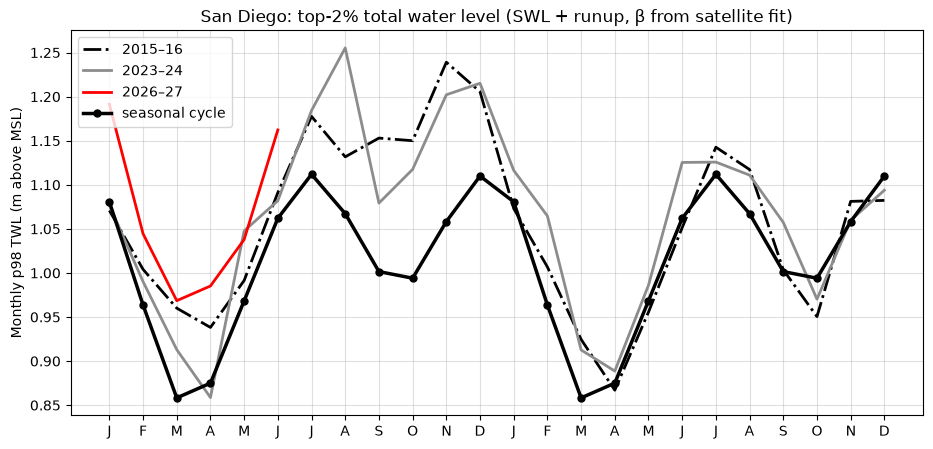

winter (DJF) climatological p98 TWL: 1.05 m above MSL
2015–16: peak departure +0.18 m
2023–24: peak departure +0.19 m
2026–27: peak departure +0.11 m


In [5]:
TWL_EVENTS = [
    (2015, "2015–16", dict(color="k", ls="-.", lw=2)),
    (2023, "2023–24", dict(color="0.55", ls="-", lw=2)),
    (2026, "2026–27", dict(color="r", ls="-", lw=2)),
]


def monthly_p98(hourly):
    """Monthly 98th percentile; months under half coverage become NaN."""
    grouped = hourly.resample("MS")
    p98 = grouped.quantile(0.98)
    p98[grouped.count() < 360] = np.nan
    return p98


p98_twl = monthly_p98(frame["twl"])
clim = p98_twl.groupby(p98_twl.index.month).mean()

fig, ax = plt.subplots(figsize=(11, 5))
months = np.arange(1, 25)
for onset, label, style in TWL_EVENTS:
    idx = pd.date_range(f"{onset}-01-01", periods=24, freq="MS")
    window = p98_twl.reindex(idx).to_numpy()
    if np.isnan(window).all():
        continue   # gauge record ends before this event
    ax.plot(months, window, label=label, **style)
ax.plot(months, np.tile(clim.to_numpy(), 2), "k-o", lw=2.5, ms=5,
        markerfacecolor="k", label="seasonal cycle", zorder=2)
ax.set_xticks(months)
ax.set_xticklabels(list("JFMAMJJASOND") * 2)
ax.set_ylabel("Monthly p98 TWL (m above MSL)")
ax.set_title(f"{MY_SITE}: top-2% total water level (SWL + runup, β from {note})")
ax.legend(loc="upper left")
ax.grid(alpha=0.4)
plt.show()

# board numbers: winter climatology and each event's peak departure
djf = clim.reindex([12, 1, 2]).mean()
print(f"winter (DJF) climatological p98 TWL: {djf:.2f} m above MSL")
for onset, label, _ in TWL_EVENTS:
    idx = pd.date_range(f"{onset}-01-01", periods=24, freq="MS")
    excess = p98_twl.reindex(idx).to_numpy() - np.tile(clim.to_numpy(), 2)
    if not np.isnan(excess).all():
        print(f"{label}: peak departure {np.nanmax(excess):+.2f} m")

## 5. Months hide events: your winter's biggest hours

A monthly 98th percentile is set by roughly the fifteenth-largest hour of the
month — but the most damaging kind of moment is a *coincidence*: a spring high
tide arriving under an elevated El Niño water level while a big swell runs. One
such event can be the story of the whole winter and still barely move a monthly
statistic. So we also look at single hours: the biggest hour of each winter, and
the record's top ten hours decomposed into exactly that trio (splitting SWL with
a 30-day mean into a slow anomaly and a fast tide + surge part, plus runup — the
three sum to TWL exactly).

**TODO (markdown):** after running the cell —

1. Note your site's single biggest hour: date, time, and peak TWL. Search for
   news from that date (plus a day or two). What happened on your coast?
2. Which ingredient is largest in your top event? Is the slow anomaly elevated —
   and is that an El Niño winter?
3. Was your winter's story a month of elevated waves, or one day? Compare what
   the monthly p98 plot (section 4) and this section each tell you.

/var/folders/x9/048rcc417d1_9fms7v44lr4h0000gn/T/ipykernel_94660/1866771910.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  sep = pd.Timedelta(min_sep)


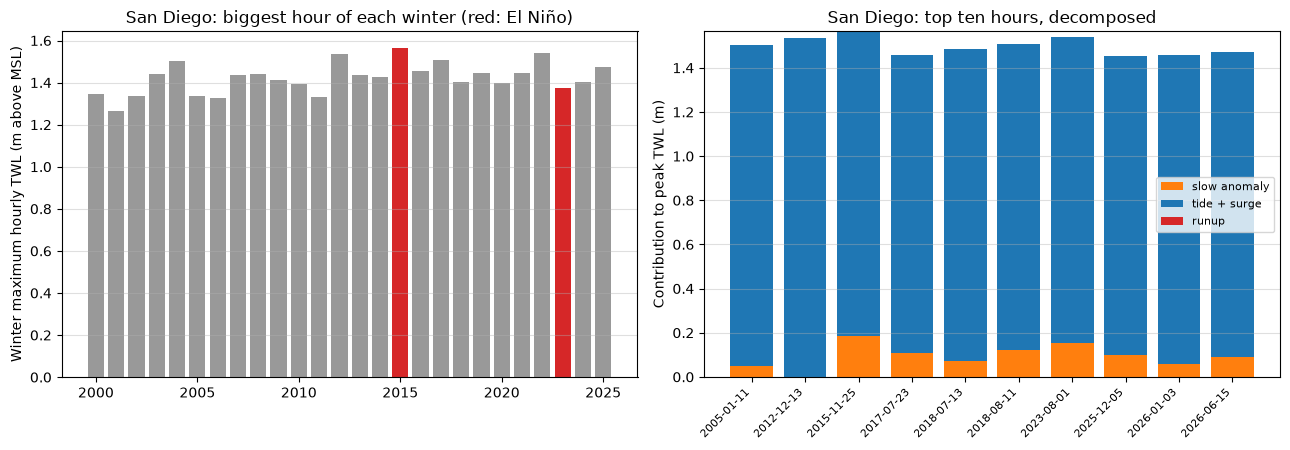

                      TWL  slow anomaly  tide + surge  runup
when                                                        
2005-01-11 17:00:00  1.50          0.05          1.46    0.0
2012-12-13 16:00:00  1.53         -0.00          1.54    0.0
2015-11-25 16:00:00  1.57          0.19          1.38    0.0
2017-07-23 04:00:00  1.46          0.11          1.35    0.0
2018-07-13 04:00:00  1.49          0.07          1.42    0.0
2018-08-11 04:00:00  1.51          0.12          1.39    0.0
2023-08-01 04:00:00  1.54          0.15          1.38    0.0
2025-12-05 16:00:00  1.45          0.10          1.36    0.0
2026-01-03 16:00:00  1.46          0.06          1.40    0.0
2026-06-15 04:00:00  1.47          0.09          1.38    0.0


In [6]:
def winter_label(index):
    """Winter year: Oct-Dec -> that year, Jan-Sep -> year - 1, so 'winter 2015'
    means October 2015 through March 2016."""
    return index.year - (index.month < 10)


def top_events(twl, n=10, min_sep="3D"):
    """The n largest hourly values at least min_sep apart, so neighboring hours
    of the same storm do not count twice."""
    sep = pd.Timedelta(min_sep)
    events = []
    for t, v in twl.dropna().sort_values(ascending=False).items():
        if all(abs(t - prev) > sep for prev, _ in events):
            events.append((t, v))
            if len(events) == n:
                break
    return events


# slow anomaly = 30-day centered mean of SWL (seasonal cycle + El Niño);
# what remains after subtracting it is the fast part: tide + storm surge
slow = frame["swl"].rolling(720, center=True, min_periods=360).mean()
fast = frame["swl"] - slow

# the biggest hour of each winter (needs at least half a winter of data)
label = winter_label(frame.index)
winter_max = frame["twl"].groupby(label).max()
winter_max[frame["twl"].groupby(label).count() < 2000] = np.nan
winter_max = winter_max.loc[2000:2025]

events = top_events(frame["twl"], n=10)
ev = pd.DataFrame([{"when": t, "TWL": v, "slow anomaly": slow[t],
                    "tide + surge": fast[t], "runup": frame.loc[t, "r2"]}
                   for t, v in events]).set_index("when").sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
colors = ["tab:red" if y in (2015, 2023) else "0.6" for y in winter_max.index]
axes[0].bar(winter_max.index, winter_max, color=colors)
axes[0].set_ylabel("Winter maximum hourly TWL (m above MSL)")
axes[0].set_title(f"{MY_SITE}: biggest hour of each winter (red: El Niño)")
axes[0].grid(alpha=0.4, axis="y")
bottom = np.zeros(len(ev))
for part, color in [("slow anomaly", "tab:orange"), ("tide + surge", "tab:blue"),
                    ("runup", "tab:red")]:
    axes[1].bar(range(len(ev)), ev[part], bottom=bottom, label=part, color=color)
    bottom += ev[part].to_numpy()
axes[1].set_xticks(range(len(ev)))
axes[1].set_xticklabels([f"{t:%Y-%m-%d}" for t in ev.index], rotation=45,
                        ha="right", fontsize=8)
axes[1].set_ylabel("Contribution to peak TWL (m)")
axes[1].set_title(f"{MY_SITE}: top ten hours, decomposed")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4, axis="y")
fig.tight_layout()
plt.show()

print(ev.round(2).to_string())

## 6. Interpret, then bring numbers to the board

**TODO (markdown):**

1. How much did runup raise your winter p98 above the tide-only "before" picture?
   Waves or water level — which ingredient dominates your site's extreme?
2. Your sea level seasonal max (notebook 11) and wave max (notebook 12) — do they
   stack in the same months at your site, or stagger? What does El Niño do to
   that timing?
3. The slope β is the softest number here. Rerun section 3 with β fixed at 0.02
   and at 0.10: how much does your winter p98 move? Bigger or smaller than your
   El Niño signal?

**For the board:** site, transect, β and its source, winter DJF p98 TWL (m), each
event's peak departure (m), and — from section 5 — your single biggest hour: its
date, peak TWL, and largest ingredient. The class synthesis question: *where along the
coast does an El Niño winter push the top-2% total water level highest, and is
that set by the ocean, the beach, or both?*

## Data notes

UHSLC hourly tide gauges; CDIP MOP v1.1 spectra; Stockdon et al. (2006) runup as
implemented in the group's `MopSusheelStockdon.m` (M. Merrifield); satellite
seasonal beach slopes from the group's CoastSat analysis. Full method, citations,
and the all-site comparison: `reference/13_el_nino_total_water_level_complete.ipynb`.